# Yards-after-catch Univariate Analysis
Quantitative analysis involves examining a single variable at a time to describe its distribution, central tendency (mean, median, mode), and dispersion (range, variance, standard deviation).
Used to identify patterns, trends, and outliers.  It is often the first step in data exploration before progressing to bivariate/multivariate analysis

# About this data
This dataset contains detailed NFL play data for seasons 2020-2021, scraped from the web and provided as part of the NFLFastR package.
372 columns per set.

## Load libraries

In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, roc_auc_score
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

## Load Data

In [2]:
# Start with first CSV file (2010)
raw_data = pd.read_csv(r"C:\MSDS\CSE6242\project\data\play_by_play_2010.csv")
# Append the remaining 2011 to 2020 CSV files to the dataframe.  Reset the index
for yr in range (2011,2020):
    raw_data = pd.concat([raw_data, pd.read_csv(r"C:\MSDS\CSE6242\project\data\play_by_play_" + str(yr) + ".csv")]).reset_index(drop=True)

In [3]:
# Extract the Season from the game_id (yyyy_##_aaa_hhh)
df_temp = raw_data.copy()
df_temp['Season'] = df_temp['game_id'].apply(lambda x:x[:4])

## Get Team statistics from play data

In [4]:
# Create an empty list to hold offensive and defensive rankings
off_ranks = []
def_ranks = []

for season in sorted(df_temp['Season'].unique()):
    games = 16 if int(season) < 2021 else 17  # NFL moved to 17 games in 2021

    off = (
        df_temp.loc[(df_temp['Season'] == season) & (df_temp['season_type'] == 'REG'), ['posteam', 'yards_gained']]
        .groupby('posteam').sum().div(games)
        .rename(columns={'yards_gained': 'off_yards_per_game'})
    )
    off['off_rank'] = off['off_yards_per_game'].rank(method='min', ascending=False).astype(int)
    off['Season'] = season
    off_ranks.append(off.reset_index())

    def_ = (
        df_temp.loc[(df_temp['Season'] == season) & (df_temp['season_type'] == 'REG'), ['defteam', 'yards_gained']]
        .groupby('defteam').sum().div(games)
        .rename(columns={'yards_gained': 'def_yards_per_game'})
    )
    def_['def_rank'] = def_['def_yards_per_game'].rank(method='min', ascending=True).astype(int)
    def_['Season'] = season
    def_ranks.append(def_.reset_index())

off_ranks = pd.concat(off_ranks).rename(columns={'posteam': 'team'})
def_ranks = pd.concat(def_ranks).rename(columns={'defteam': 'team'})

df_temp = df_temp.merge(
    off_ranks[['Season', 'team', 'off_yards_per_game', 'off_rank']],
    left_on=['Season', 'posteam'], right_on=['Season', 'team'], how='left'
).drop(columns='team')

df_temp = df_temp.merge(
    def_ranks[['Season', 'team', 'def_yards_per_game', 'def_rank']],
    left_on=['Season', 'defteam'], right_on=['Season', 'team'], how='left'
).drop(columns='team')

df_temp.head()

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,xyac_median_yardage,xyac_success,xyac_fd,xpass,pass_oe,Season,off_yards_per_game,off_rank,def_yards_per_game,def_rank
0,1,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2010,NaN,NaN,NaN,NaN
1,36,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,NaN,NaN,NaN,NaN,NaN,2010,268.8125,31.0,336.875,19.0
2,58,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,6.0,0.690780,0.224250,0.502033,49.796659,2010,268.8125,31.0,336.875,19.0
3,82,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,NaN,NaN,NaN,0.499817,-49.981695,2010,268.8125,31.0,336.875,19.0
4,103,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,1.0,0.998045,0.998045,0.962868,3.713167,2010,268.8125,31.0,336.875,19.0


## Create rolling 3-year Ranking for each Team

In [5]:
name_to_abbr = {
    'Atlanta Falcons': 'ATL',
    'Arizona Cardinals': 'ARI',
    'Baltimore Ravens': 'BAL',
    'Buffalo Bills': 'BUF',
    'Carolina Panthers': 'CAR',
    'Chicago Bears': 'CHI',
    'Cincinnati Bengals': 'CIN',
    'Cleveland Browns': 'CLE',
    'Dallas Cowboys': 'DAL',
    'Denver Broncos': 'DEN',
    'Detroit Lions': 'DET',
    'Green Bay Packers': 'GB',
    'Houston Texans': 'HOU',
    'Indianapolis Colts': 'IND',
    'Jacksonville Jaguars': 'JAX',
    'Kansas City Chiefs': 'KC',
    'St. Louis Rams': 'LA',
    'San Diego Chargers': 'LAC',
    'Oakland Raiders': 'LV',
    'Miami Dolphins': 'MIA',
    'Minnesota Vikings': 'MIN',
    'New England Patriots': 'NE',
    'New Orleans Saints': 'NO',
    'New York Giants': 'NYG',
    'New York Jets': 'NYJ',
    'Philadelphia Eagles': 'PHI',
    'Pittsburgh Steelers': 'PIT',
    'Seattle Seahawks': 'SEA',
    'San Francisco 49ers': 'SF',
    'Tampa Bay Buccaneers': 'TB',
    'Tennessee Titans': 'TEN',
    'Washington Redskins': 'WAS',
}

# Need to use external data for 2007-2009 to create the 3-year rolling average for the 1st 3 years of data (2010-2012)
# ── Load Excel data for 2007, 2008, 2009 ──────────────────────────────────────
def load_external_year(year):
    off = pd.read_excel(f'data\\{year} ranks.xlsx', sheet_name='offense')
    def_ = pd.read_excel(f'data\\{year} ranks.xlsx', sheet_name='defense')
    off['team'] = off['Team'].map(name_to_abbr)
    def_['team'] = def_['Team'].map(name_to_abbr)
    off = off.set_index('team')[['YDS/G']].rename(columns={'YDS/G': 'off_ypg'})
    def_ = def_.set_index('team')[['YDS/G allowed']].rename(columns={'YDS/G allowed': 'def_ypg'})
    return off, def_

ext_off = {}; ext_def = {}
for yr in [2007, 2008, 2009]:
    ext_off[yr], ext_def[yr] = load_external_year(yr)

# ── Helper: get per-team YPG for a season from df_temp ───────────────────────
def get_ypg_from_df(season_str):
    s = df_temp.loc[(df_temp['Season'] == season_str) & (df_temp['season_type'] == 'REG')]
    off = s.groupby('posteam')['yards_gained'].sum().div(16).rename('off_ypg')
    def_ = s.groupby('defteam')['yards_gained'].sum().div(16).rename('def_ypg')
    return off.to_frame(), def_.to_frame()

# ── Helper: average YPG across a list of (off_df, def_df) tuples ─────────────
def avg_ypg(frames_off, frames_def):
    off_avg = pd.concat(frames_off).groupby(level=0)['off_ypg'].mean().to_frame()
    def_avg = pd.concat(frames_def).groupby(level=0)['def_ypg'].mean().to_frame()
    return off_avg, def_avg

# ── Apply 2009 lagged data → 2010 season (1-year lag) ────────────────────────
prev_off_2009 = pd.read_excel('data\\2009 ranks.xlsx', sheet_name='offense')
prev_def_2009 = pd.read_excel('data\\2009 ranks.xlsx', sheet_name='defense')
prev_off_2009['team'] = prev_off_2009['Team'].map(name_to_abbr)
prev_def_2009['team'] = prev_def_2009['Team'].map(name_to_abbr)
prev_off_2009 = prev_off_2009.rename(columns={'Rank': 'prev_off_rank', 'YDS/G': 'prev_off_ypg'}).set_index('team')[['prev_off_ypg', 'prev_off_rank']]
prev_def_2009 = prev_def_2009.rename(columns={'Rank': 'prev_def_rank', 'YDS/G allowed': 'prev_def_ypg'}).set_index('team')[['prev_def_ypg', 'prev_def_rank']]

mask_2010 = df_temp['Season'] == '2010'
df_temp.loc[mask_2010, 'prev_off_ypg']  = df_temp.loc[mask_2010, 'posteam'].map(prev_off_2009['prev_off_ypg'])
df_temp.loc[mask_2010, 'prev_off_rank'] = df_temp.loc[mask_2010, 'posteam'].map(prev_off_2009['prev_off_rank'])
df_temp.loc[mask_2010, 'prev_def_ypg']  = df_temp.loc[mask_2010, 'defteam'].map(prev_def_2009['prev_def_ypg'])
df_temp.loc[mask_2010, 'prev_def_rank'] = df_temp.loc[mask_2010, 'defteam'].map(prev_def_2009['prev_def_rank'])

# ── Apply 3-year lagged data → 2010 season (avg of 2007, 2008, 2009) ─────────
off_3yr, def_3yr = avg_ypg(
    [ext_off[2007], ext_off[2008], ext_off[2009]],
    [ext_def[2007], ext_def[2008], ext_def[2009]]
)
off_3yr['off_3yr_rank'] = off_3yr['off_ypg'].rank(method='min', ascending=False).astype(int)
def_3yr['def_3yr_rank'] = def_3yr['def_ypg'].rank(method='min', ascending=True).astype(int)

df_temp.loc[mask_2010, 'prev_off_3yr_ypg']  = df_temp.loc[mask_2010, 'posteam'].map(off_3yr['off_ypg'])
df_temp.loc[mask_2010, 'prev_off_3yr_rank'] = df_temp.loc[mask_2010, 'posteam'].map(off_3yr['off_3yr_rank'])
df_temp.loc[mask_2010, 'prev_def_3yr_ypg']  = df_temp.loc[mask_2010, 'defteam'].map(def_3yr['def_ypg'])
df_temp.loc[mask_2010, 'prev_def_3yr_rank'] = df_temp.loc[mask_2010, 'defteam'].map(def_3yr['def_3yr_rank'])

# ── Loop over all subsequent seasons ─────────────────────────────────────────
for season in sorted(df_temp['Season'].unique()):
    season = str(season)
    prev_season = str(int(season) - 1)
    if prev_season == '2009':
        continue  # already handled above

    # ── 1-year lag (from df_temp) ──
    off_lag, def_lag = get_ypg_from_df(prev_season)
    off_lag['prev_off_rank'] = off_lag['off_ypg'].rank(method='min', ascending=False).astype(int)
    off_lag = off_lag.rename(columns={'off_ypg': 'prev_off_ypg'})
    def_lag['prev_def_rank'] = def_lag['def_ypg'].rank(method='min', ascending=True).astype(int)
    def_lag = def_lag.rename(columns={'def_ypg': 'prev_def_ypg'})

    # ── 3-year lag ──
    prev2, prev3 = str(int(season) - 2), str(int(season) - 3)

    # collect offense frames for 3 years
    frames_off, frames_def = [], []
    for py in [prev_season, prev2, prev3]:
        py_int = int(py)
        if py_int in ext_off:                        # from Excel (2007-2009)
            frames_off.append(ext_off[py_int])
            frames_def.append(ext_def[py_int])
        elif py_int >= 2010:                         # from df_temp
            o, d = get_ypg_from_df(py)
            frames_off.append(o)
            frames_def.append(d)
        # if year < 2007, skip (not enough history, ranks will just use what's available)

    off_3, def_3 = avg_ypg(frames_off, frames_def)
    off_3['off_3yr_rank'] = off_3['off_ypg'].rank(method='min', ascending=False).astype(int)
    def_3['def_3yr_rank'] = def_3['def_ypg'].rank(method='min', ascending=True).astype(int)

    # ── Write to df_temp ──
    mask = df_temp['Season'] == season
    df_temp.loc[mask, 'prev_off_ypg']      = df_temp.loc[mask, 'posteam'].map(off_lag['prev_off_ypg'])
    df_temp.loc[mask, 'prev_off_rank']     = df_temp.loc[mask, 'posteam'].map(off_lag['prev_off_rank'])
    df_temp.loc[mask, 'prev_def_ypg']      = df_temp.loc[mask, 'defteam'].map(def_lag['prev_def_ypg'])
    df_temp.loc[mask, 'prev_def_rank']     = df_temp.loc[mask, 'defteam'].map(def_lag['prev_def_rank'])

    df_temp.loc[mask, 'prev_off_3yr_ypg']  = df_temp.loc[mask, 'posteam'].map(off_3['off_ypg'])
    df_temp.loc[mask, 'prev_off_3yr_rank'] = df_temp.loc[mask, 'posteam'].map(off_3['off_3yr_rank'])
    df_temp.loc[mask, 'prev_def_3yr_ypg']  = df_temp.loc[mask, 'defteam'].map(def_3['def_ypg'])
    df_temp.loc[mask, 'prev_def_3yr_rank'] = df_temp.loc[mask, 'defteam'].map(def_3['def_3yr_rank'])

df_temp.head()

,play_id,game_id,old_game_id,home_team,away_team,season_type,week,posteam,posteam_type,defteam,...,def_yards_per_game,def_rank,prev_off_ypg,prev_off_rank,prev_def_ypg,prev_def_rank,prev_off_3yr_ypg,prev_off_3yr_rank,prev_def_3yr_ypg,prev_def_3yr_rank
0,1,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,36,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,336.875,19.0,344.4,14.0,372.8,29.0,351.433333,9.0,361.933333,29.0
2,58,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,336.875,19.0,344.4,14.0,372.8,29.0,351.433333,9.0,361.933333,29.0
3,82,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,336.875,19.0,344.4,14.0,372.8,29.0,351.433333,9.0,361.933333,29.0
4,103,2010_01_ARI_STL,2010091208,LA,ARI,REG,1,ARI,away,LA,...,336.875,19.0,344.4,14.0,372.8,29.0,351.433333,9.0,361.933333,29.0


### QA

In [6]:
# QA team data for "LA"
df_temp[['Season','def_rank','prev_def_rank','prev_def_3yr_rank']].loc[df_temp['defteam']=='LA'].drop_duplicates()

,Season,def_rank,prev_def_rank,prev_def_3yr_rank
1,2010,19.0,29.0,29.0
49946,2011,22.0,19.0,28.0
98444,2012,14.0,22.0,24.0
144523,2013,15.0,14.0,15.0
194726,2014,17.0,15.0,13.0
244325,2015,23.0,17.0,14.0
291919,2016,9.0,23.0,17.0
339809,2017,19.0,9.0,16.0
388586,2018,19.0,19.0,18.0
436790,2019,13.0,19.0,16.0


In [7]:
# QA with "NO"
df_temp[['Season','posteam','prev_off_3yr_rank']].loc[df_temp['posteam']=='NO'].drop_duplicates()
# Really good offense with Drew Brees

,Season,posteam,prev_off_3yr_rank
2180,2010,NO,1.0
49410,2011,NO,1.0
98614,2012,NO,1.0
144702,2013,NO,1.0
195110,2014,NO,1.0
243598,2015,NO,2.0
292813,2016,NO,2.0
340523,2017,NO,1.0
389552,2018,NO,1.0
436282,2019,NO,1.0


## Data Cleaning

In [8]:
filtered_data = df_temp.copy()
print("Started with: " + str(len(filtered_data)))
# --------------- Define the filtering criteria for YAC-related plays here ---------------
# Must be a pass play
filtered_data = filtered_data.loc[(filtered_data['play_type']=='pass')].reset_index(drop=True)
# Cannot be an incomplete pass
filtered_data = filtered_data.loc[(filtered_data['incomplete_pass']==0)].reset_index(drop=True)
# Cannot be a sack
filtered_data = filtered_data.loc[(filtered_data['sack']==0)].reset_index(drop=True)
# Cannot be an interception
filtered_data = filtered_data.loc[(filtered_data['interception']==0)].reset_index(drop=True)
# Cannot be a fumble
filtered_data = filtered_data.loc[(filtered_data['fumble']==0)].reset_index(drop=True)
# Must be a down play (i.e, no 2-point conversion)
filtered_data = filtered_data.loc[(filtered_data['down']!='NA')].reset_index(drop=True)
# Cannot result in an offensive penalty (i.e., declined penalties OK!)
filtered_data = filtered_data.loc[(filtered_data['penalty']==0)].reset_index(drop=True)
# Cannot result in a touchdown (i.e., There is no YAC for TDs)
filtered_data = filtered_data.loc[(filtered_data['touchdown']==0)].reset_index(drop=True)
print("Ended with: " + str(len(filtered_data)))

Started with: 483001
Ended with: 104940


In [9]:
# Dataframe cleaning & reorganizing
df = filtered_data.copy()

# --- Define column groups ---
team_variables = ['Season','posteam', 'posteam_type', 'defteam','off_rank','prev_off_rank','prev_off_3yr_rank','def_rank','prev_def_rank','prev_def_3yr_rank']
situation_variables = ['down', 'qtr', 'quarter_seconds_remaining', 'half_seconds_remaining', 'game_seconds_remaining', 'yrdln', 'goal_to_go', 'ydstogo']
related_to_target = ['desc', 'sp', 'posteam_score', 'posteam_score_post', 'defteam_score', 'defteam_score_post', 'first_down', 'yards_gained', 'air_yards', 'yards_after_catch', 'incomplete_pass']
pass_variables = ['play_type','pass_length','pass_location']
action_variables = ['shotgun','no_huddle','qb_dropback','qb_scramble']
#result_variables = ['air_yards','yards_after_catch']

df = filtered_data[['game_id', 'two_point_attempt', 'interception', 'fumble_lost', 'fourth_down_failed'] + situation_variables + related_to_target + team_variables + pass_variables + action_variables].copy()

# --- Column cleaning
# --- astype(int) for boolean columns
cols_to_convert = ['incomplete_pass', 'qb_dropback','first_down']
df[cols_to_convert] = df[cols_to_convert].astype(int)

# --- Turnover ---
df['turnover'] = (
    (df['interception'] == 1) |
    (df['fumble_lost'] == 1) |
    (df['fourth_down_failed'] == 1)
).astype(int)
df = df.drop(columns=['interception', 'fumble_lost', 'fourth_down_failed'])

# --- Pass Length ---
completed_pass = (df['incomplete_pass'] == 0) & (df['play_type'] == 'pass')
df.loc[completed_pass & (df['air_yards'] <= 15), 'pass_length'] = 'short'
df.loc[completed_pass & (df['air_yards'] > 15), 'pass_length'] = 'deep'

# --- Scoring Plays ---
df['posteam_scoring_play'] = (df['posteam_score_post'] - df['posteam_score'] > 0).astype(int)
df['defteam_scoring_play'] = (df['defteam_score_post'] - df['defteam_score'] > 0).astype(int)
related_to_target += ['turnover', 'posteam_scoring_play', 'defteam_scoring_play']


# --- Down / Two Point Attempt ---
df['down'] = df['down'].fillna('two_point_attempt').astype(str).str.replace(r'\.0', '', regex=True)
df = df.drop(columns=['two_point_attempt'])

# --- Yards Until Endzone ---
df[['yrdln_team', 'yrdln_num']] = df['yrdln'].str.split(' ', expand=True)
df['yards_until_endzone'] = np.where(df['yrdln_team'] == df['posteam'], 100 - df['yrdln_num'].astype(int), df['yrdln_num'].astype(int))
df = df.drop(columns=['yrdln_team', 'yrdln_num', 'yrdln'])
situation_variables = [c for c in situation_variables if c not in ('yrdln', 'two_point_attempt')] + ['yards_until_endzone']

# --- Score Differential ---
df['score_diff'] = df['posteam_score']-df['defteam_score']
situation_variables.append('score_diff')  

# --- Final Column Order ---
#df = df[['game_id'] + situation_variables + team_variables + related_to_target + pass_variables + action_variables + result_variables]
df = df[['game_id'] + situation_variables + team_variables + related_to_target + pass_variables + action_variables]

df.head()
#print(df.dtypes)

,game_id,down,qtr,quarter_seconds_remaining,half_seconds_remaining,game_seconds_remaining,goal_to_go,ydstogo,yards_until_endzone,score_diff,...,turnover,posteam_scoring_play,defteam_scoring_play,play_type,pass_length,pass_location,shotgun,no_huddle,qb_dropback,qb_scramble
0,2010_01_ARI_STL,1,1,895.0,1795.0,3595.0,0,10,78,0.0,...,0,0,0,pass,short,right,0,0,1,0
1,2010_01_ARI_STL,3,1,823.0,1723.0,3523.0,0,5,73,0.0,...,0,0,0,pass,short,right,1,0,1,0
2,2010_01_ARI_STL,1,1,797.0,1697.0,3497.0,0,10,55,0.0,...,0,0,0,pass,short,right,1,0,1,0
3,2010_01_ARI_STL,2,1,727.0,1627.0,3427.0,0,8,36,0.0,...,0,0,0,pass,short,right,1,0,1,0
4,2010_01_ARI_STL,1,1,650.0,1550.0,3350.0,0,10,32,0.0,...,0,0,0,pass,short,left,0,0,1,0


In [10]:
df.to_parquet('data.parquet', compression='snappy')

In [11]:
len(pd.read_parquet('data.parquet'))

104940

## Total Pass Yards Gained

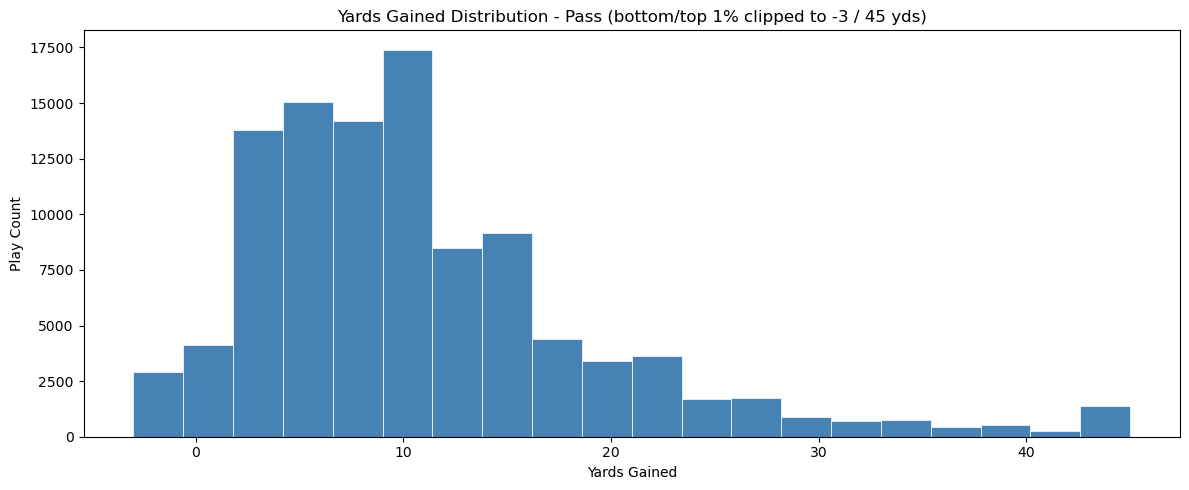

In [12]:
temp = df.copy().loc[df['play_type']=='pass'].reset_index(drop=True)

low = temp['yards_gained'].quantile(0.01)
high = temp['yards_gained'].quantile(0.99)

clipped = temp['yards_gained'].dropna().clip(lower=low, upper=high)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(clipped, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Yards Gained')
ax.set_ylabel('Play Count')
ax.set_title(f'Yards Gained Distribution - Pass (bottom/top 1% clipped to {low:.0f} / {high:.0f} yds)')
plt.tight_layout()
plt.show()

## Air Yards

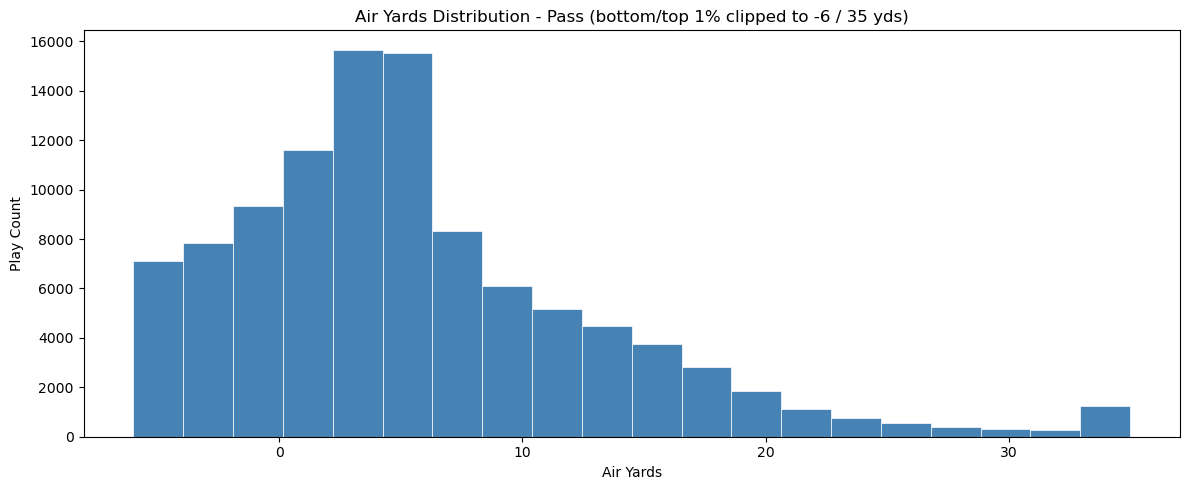

In [13]:
temp_ay = df.copy().loc[df['play_type']=='pass'].reset_index(drop=True)

low = temp_ay['air_yards'].quantile(0.01)
high = temp_ay['air_yards'].quantile(0.99)

clipped = temp_ay['air_yards'].dropna().clip(lower=low, upper=high)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(clipped, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Air Yards')
ax.set_ylabel('Play Count')
ax.set_title(f'Air Yards Distribution - Pass (bottom/top 1% clipped to {low:.0f} / {high:.0f} yds)')
plt.tight_layout()
plt.show()

## Yards after catch distribution

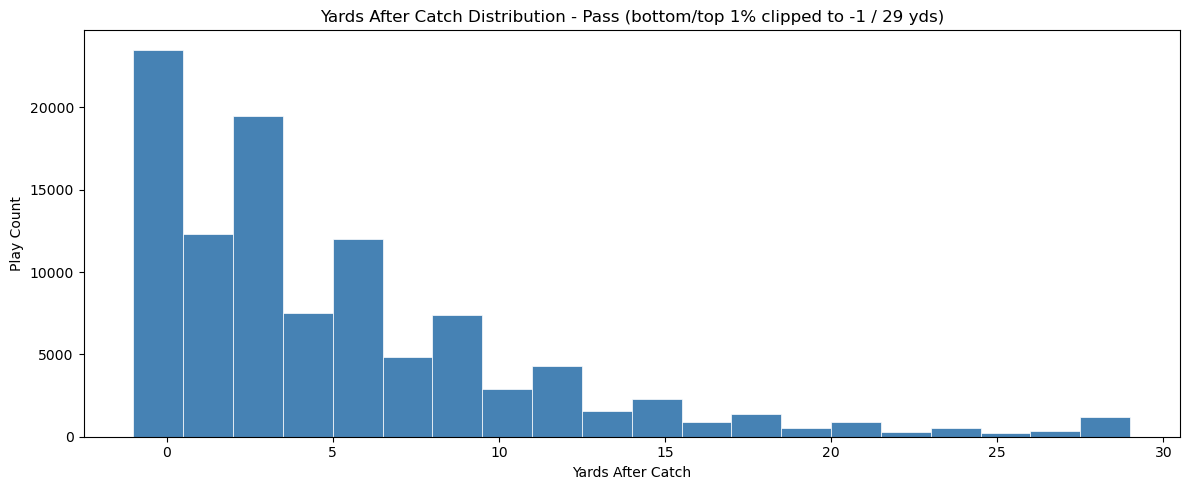

In [14]:
temp_yac = df.copy().loc[df['play_type']=='pass'].reset_index(drop=True)

low = temp_yac['yards_after_catch'].quantile(0.01)
high = temp_yac['yards_after_catch'].quantile(0.99)

clipped = temp_yac['yards_after_catch'].dropna().clip(lower=low, upper=high)

fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(clipped, bins=20, color='steelblue', edgecolor='white', linewidth=0.5)

ax.set_xlabel('Yards After Catch')
ax.set_ylabel('Play Count')
ax.set_title(f'Yards After Catch Distribution - Pass (bottom/top 1% clipped to {low:.0f} / {high:.0f} yds)')
plt.tight_layout()
plt.show()

## Univariate Analysis


Variable: down


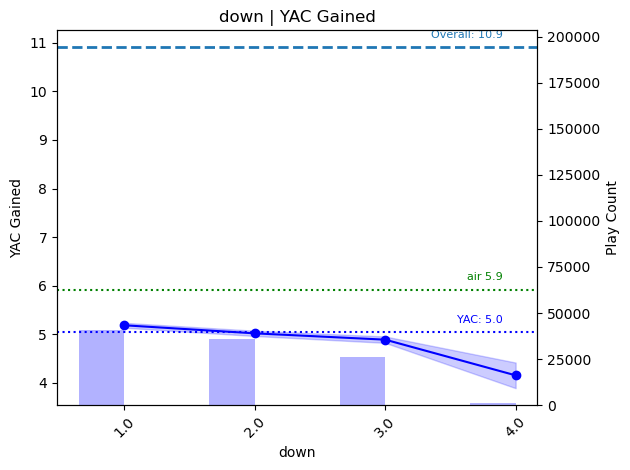


Variable: qtr


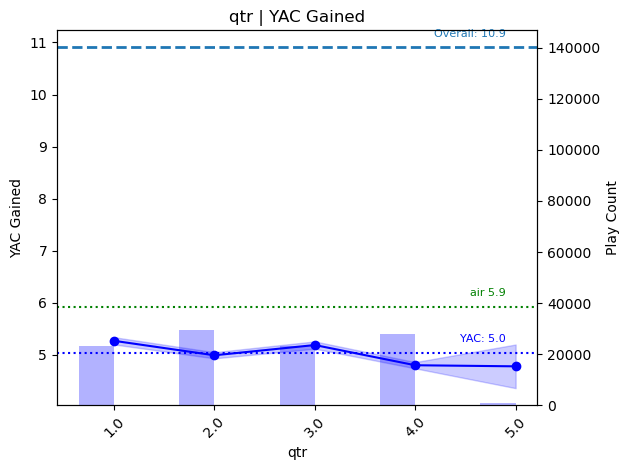


Variable: quarter_seconds_remaining


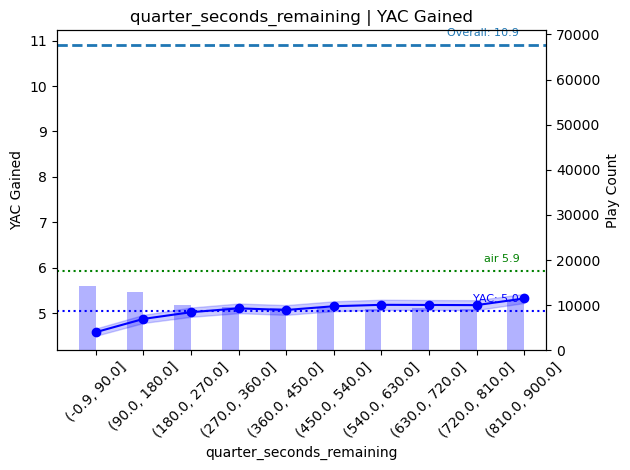


Variable: half_seconds_remaining


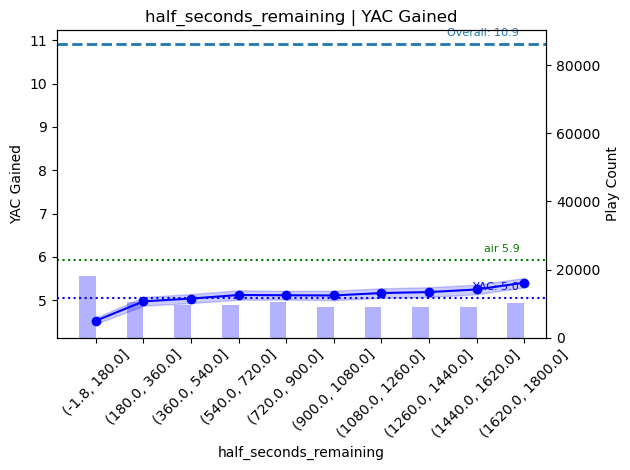


Variable: game_seconds_remaining


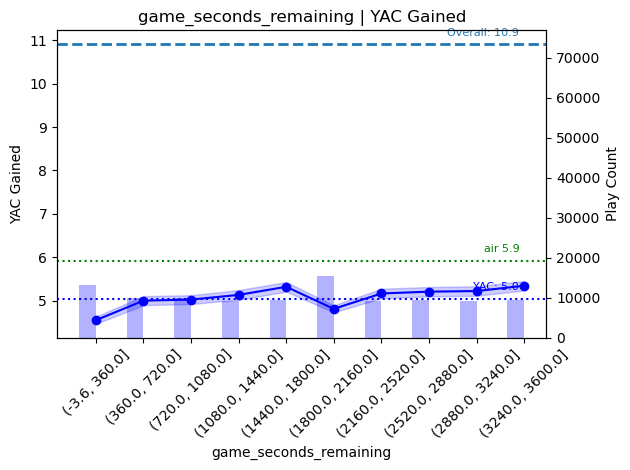


Variable: goal_to_go


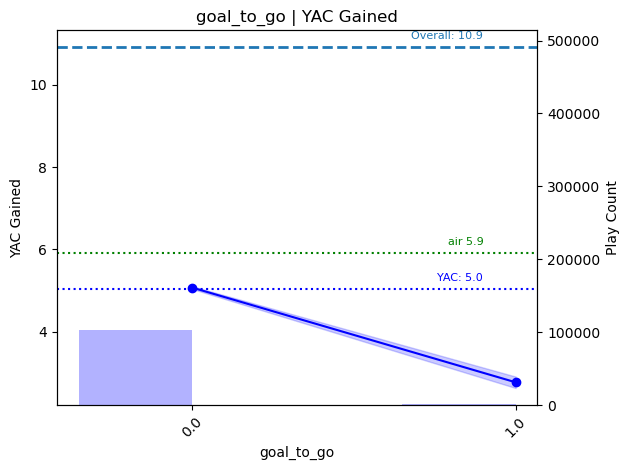


Variable: ydstogo


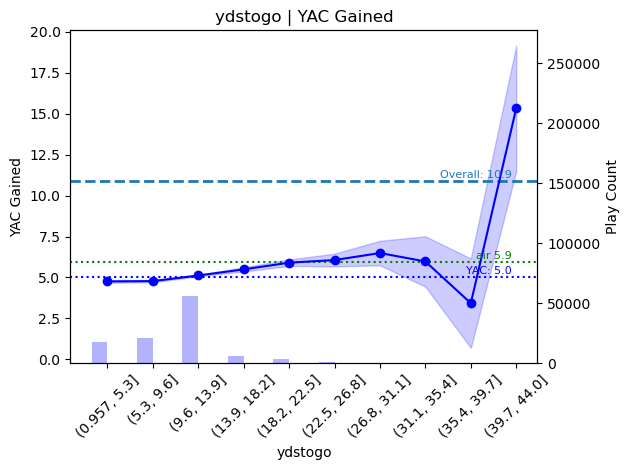


Variable: yards_until_endzone


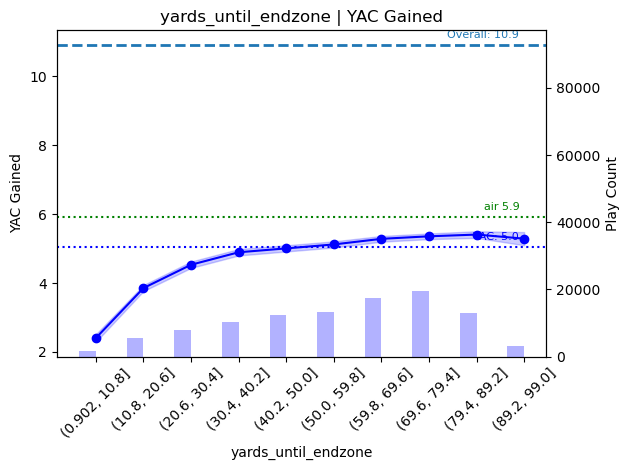


Variable: score_diff


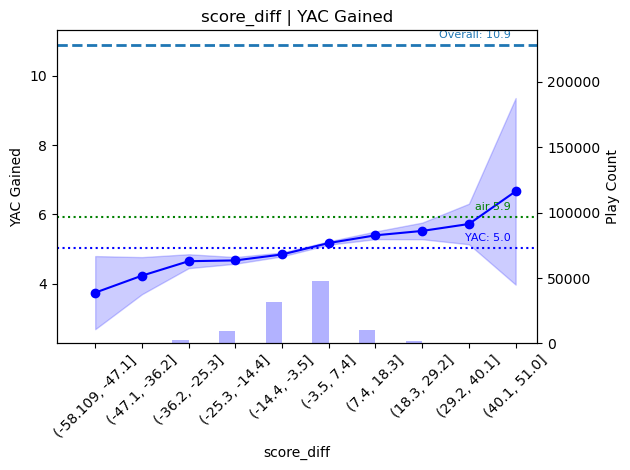


Variable: Season


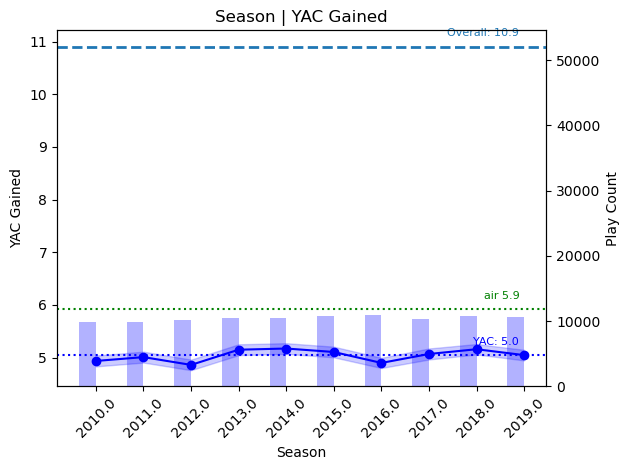


Variable: posteam


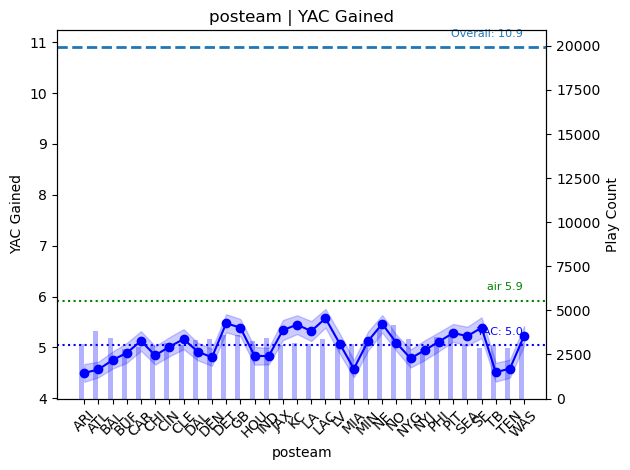


Variable: posteam_type


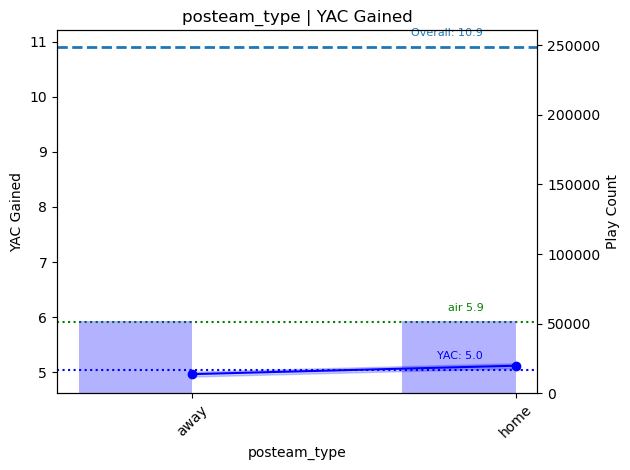


Variable: defteam


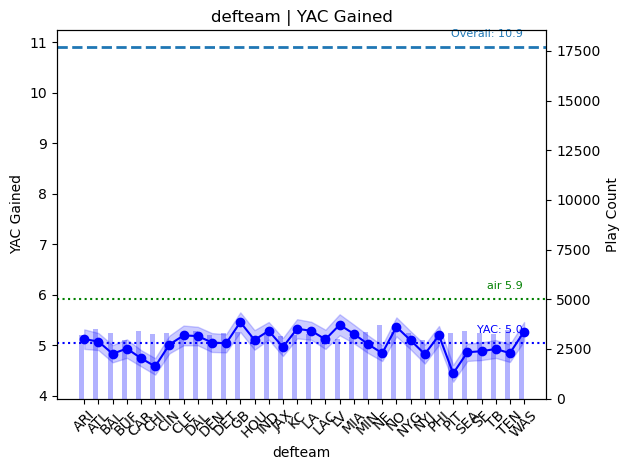


Variable: off_rank


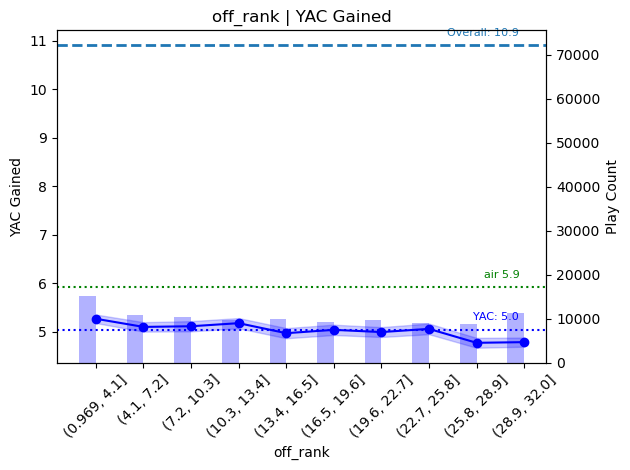


Variable: prev_off_rank


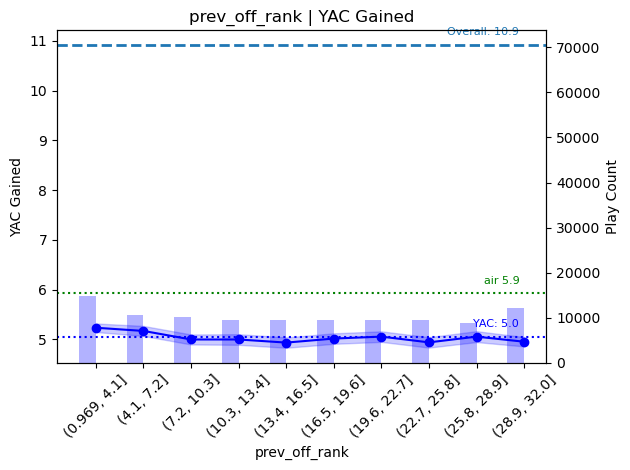


Variable: prev_off_3yr_rank


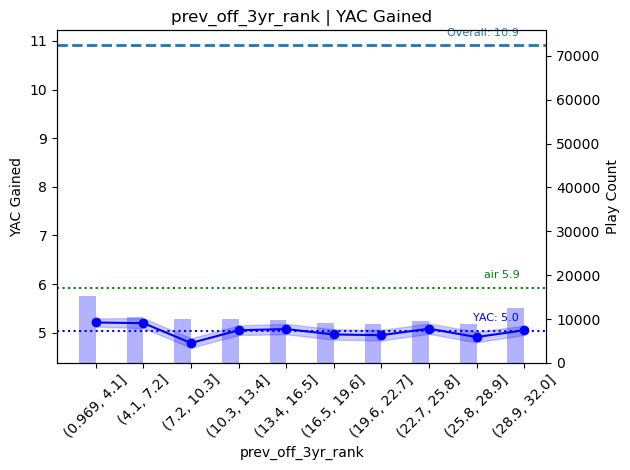


Variable: def_rank


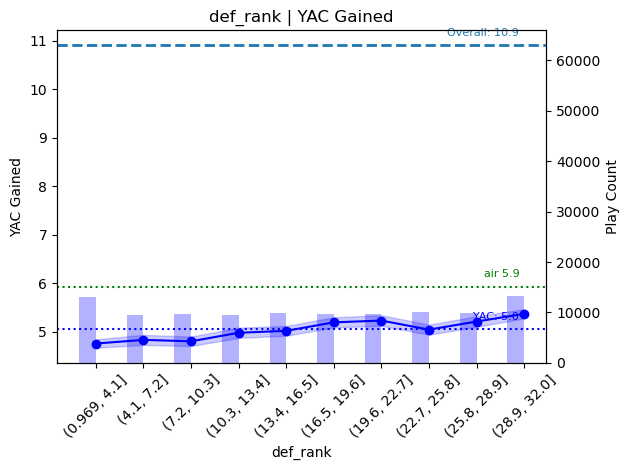


Variable: prev_def_rank


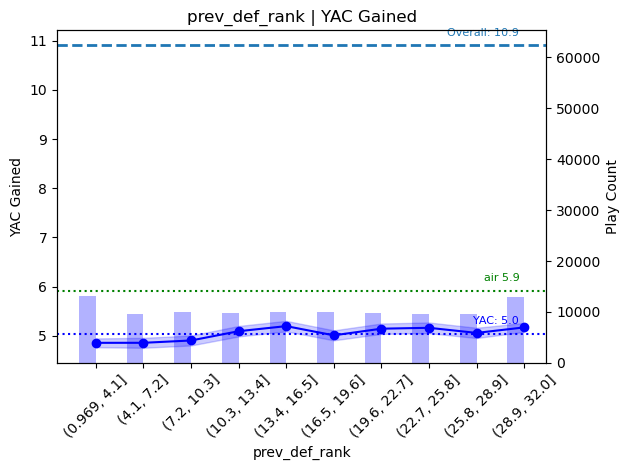


Variable: prev_def_3yr_rank


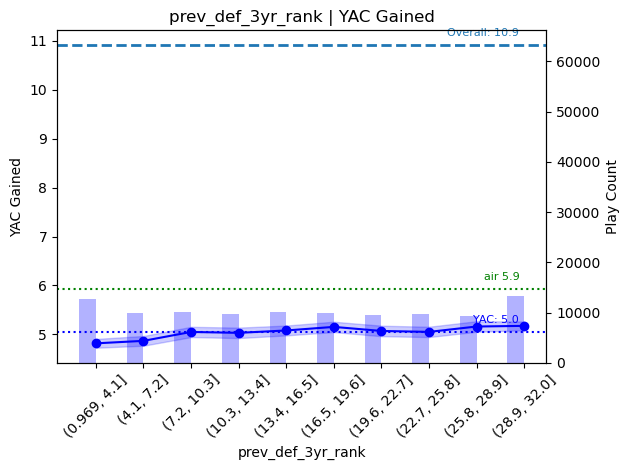


Variable: play_type

Variable: pass_length


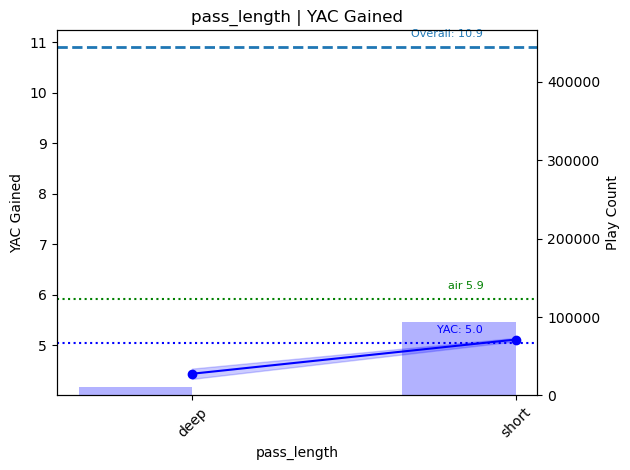


Variable: pass_location


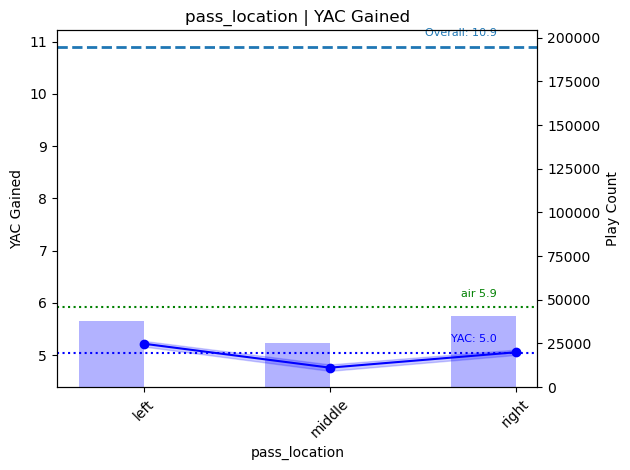


Variable: shotgun


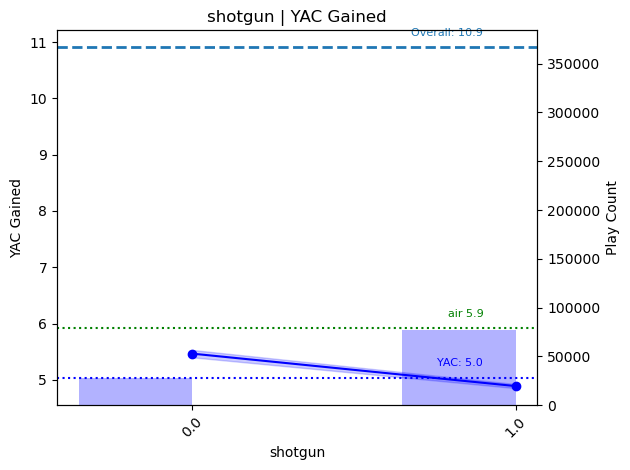


Variable: no_huddle


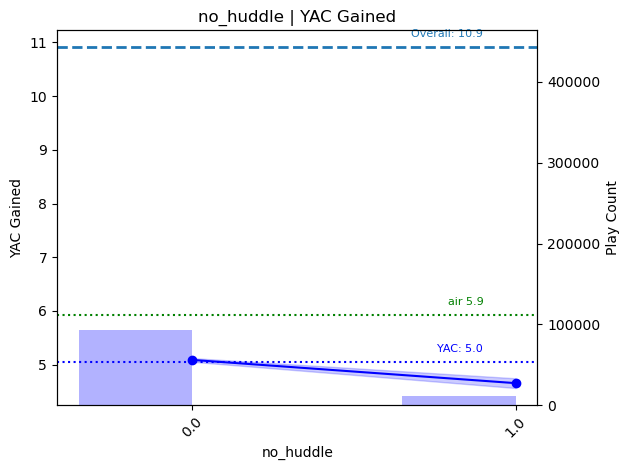


Variable: qb_dropback

Variable: qb_scramble


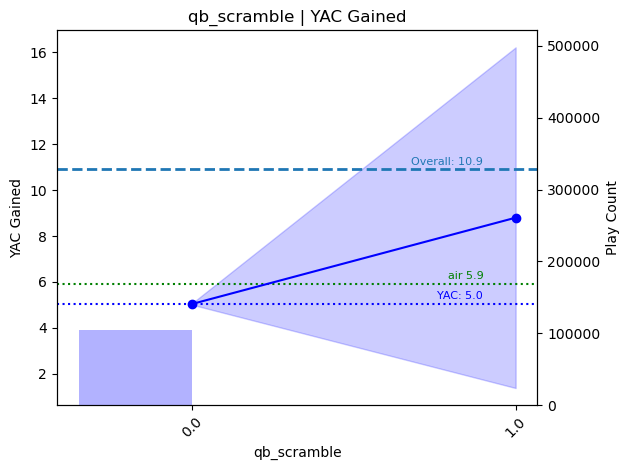


Variable: air_yards


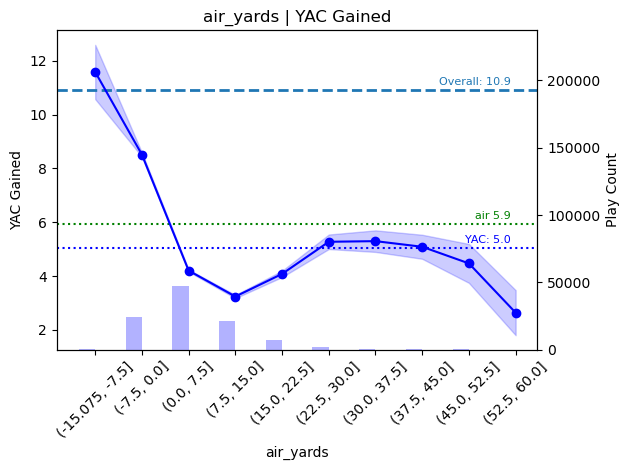

In [19]:
univariate_variables = situation_variables + team_variables + pass_variables + action_variables
univariate_variables.append('air_yards')

def is_continuous(series):
    if series.nunique() > 20:
        try:
            series.astype(float)
            return True
        except (ValueError, TypeError):
            return False
    return False
    
for variable in univariate_variables:
    print(f"\nVariable: {variable}")

    pass_data = df[df['play_type'] == 'pass'].copy()

    overall_avg = pass_data['yards_gained'].mean()
    yac_avg = pass_data['yards_after_catch'].mean()
    air_yards_avg = pass_data['air_yards'].mean()

    play_type_configs = [
        ('pass', pass_data, 'blue')
    ]

    fig, ax1 = plt.subplots()
    ax1.axhline(y=overall_avg, color='#1F77B4', linestyle='--', linewidth=2)
    ax1.axhline(y=yac_avg, color='blue', linestyle=':', linewidth=1.5)
    ax1.axhline(y=air_yards_avg, color='green', linestyle=':', linewidth=1.5)

    all_counts = []
    grouped_by_pt = {}

    full_data = df[[variable, 'yards_after_catch']].dropna().copy()
    if full_data[variable].nunique() <= 1 or len(full_data) == 0:
        plt.close()
        continue

    continuous = is_continuous(full_data[variable])
    shared_bins = None
    if continuous:
        _, shared_bins = pd.cut(full_data[variable].astype(float), bins=10, retbins=True)

    for play_type, pt_data, color in play_type_configs:
        data = pt_data[[variable, 'yards_after_catch']].dropna().copy()
        if len(data) == 0:
            continue

        if continuous:
            data[variable] = pd.cut(data[variable].astype(float), bins=shared_bins)

        grouped = data.groupby(variable).agg(
            avg_yards=('yards_after_catch', 'mean'),
            sigma=('yards_after_catch', 'std'),
            play_count=('yards_after_catch', 'count')
        ).reset_index()

        if continuous:
            grouped = grouped.sort_values(variable)
        else:
            try:
                grouped[variable] = grouped[variable].astype(float)
                grouped = grouped.sort_values(variable)
            except (ValueError, TypeError):
                grouped = grouped.sort_values(variable)

        grouped[variable] = grouped[variable].astype(str)
        grouped_by_pt[play_type] = (grouped, color)

    if not grouped_by_pt:
        plt.close()
        continue

    if continuous:
        all_buckets = list(list(grouped_by_pt.values())[0][0][variable])
    else:
        all_buckets = set()
        for play_type, (grouped, color) in grouped_by_pt.items():
            all_buckets.update(grouped[variable].tolist())
        try:
            all_buckets = sorted(all_buckets, key=lambda x: float(x))
        except (ValueError, TypeError):
            all_buckets = sorted(all_buckets)

    x = np.arange(len(all_buckets))
    bucket_idx = {b: i for i, b in enumerate(all_buckets)}
    bar_width = 0.35
    ax2 = ax1.twinx()

    for i, (play_type, (grouped, color)) in enumerate(grouped_by_pt.items()):
        buckets = grouped[variable].tolist()
        xi = np.array([bucket_idx[b] for b in buckets if b in bucket_idx])
        filtered = grouped[grouped[variable].isin(bucket_idx.keys())]
        means = filtered['avg_yards'].values
        sigma = filtered['sigma'].values
        counts = filtered['play_count'].values
        all_counts.extend(counts)

        margin = 1.645 * sigma / np.sqrt(counts)
        lower = means - margin
        upper = means + margin

        offset = (i - 0.5) * bar_width
        ax1.plot(xi, means, marker='o', color=color)
        ax1.fill_between(xi, lower, upper, alpha=0.2, color=color)
        ax2.bar(xi + offset, counts, width=bar_width, alpha=0.3, color=color)

    xmax = len(all_buckets) - 1
    ax1.annotate(f'Overall: {overall_avg:.1f}', xy=(xmax, overall_avg), xytext=(xmax - 0.1, overall_avg + 0.2), color='#1F77B4', fontsize=8, ha='right')
    ax1.annotate(f'YAC: {yac_avg:.1f}', xy=(xmax, yac_avg), xytext=(xmax - 0.1, yac_avg + 0.2), color='blue', fontsize=8, ha='right')
    ax1.annotate(f'air {air_yards_avg:.1f}', xy=(xmax, air_yards_avg), xytext=(xmax - 0.1, air_yards_avg + 0.2), color='green', fontsize=8, ha='right')

    ax1.set_xlabel(variable)
    ax1.set_ylabel("YAC Gained")
    ax1.set_xticks(x)
    ax1.set_xticklabels(all_buckets, rotation=45)
    ax2.set_ylabel("Play Count")
    ax2.set_ylim(0, 5 * max(all_counts))

    plt.title(f"{variable} | YAC Gained")
    plt.tight_layout()
    plt.show()

### Correlation

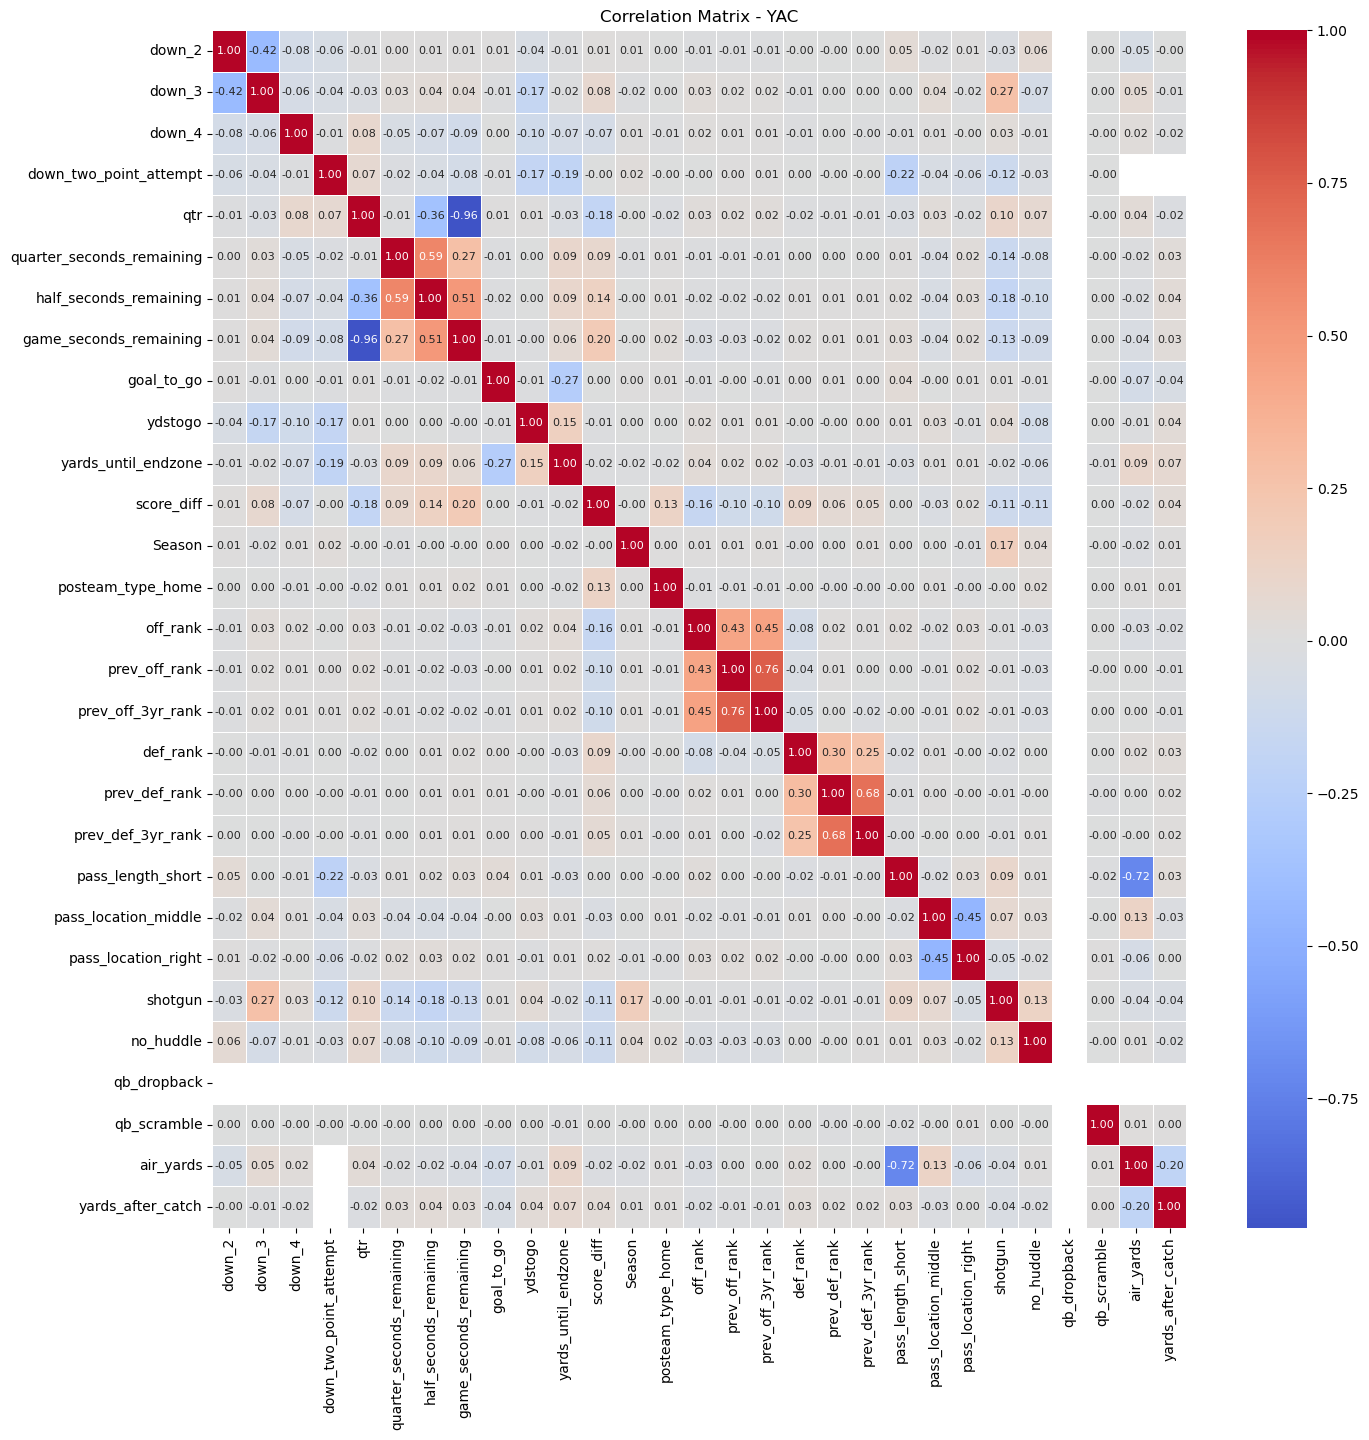

In [20]:
corr_data = df[[c for c in univariate_variables if c not in ['posteam','defteam']] + ['yards_after_catch']].loc[df['play_type']=='pass'].copy()

# one hot encode categoricals, coerce rest to numeric
encoded_frames = []
for col in corr_data.columns:
    try:
        encoded_frames.append(corr_data[[col]].astype(float))
    except (ValueError, TypeError):
        dummies = pd.get_dummies(corr_data[col], prefix=col, drop_first=True)
        encoded_frames.append(dummies)

corr_data_encoded = pd.concat(encoded_frames, axis=1)

corr_matrix = corr_data_encoded.corr()

fig, ax = plt.subplots(figsize=(max(14, len(corr_matrix) * 0.5), max(12, len(corr_matrix) * 0.5)))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    annot_kws={'size': max(6, 10 - len(corr_matrix) // 10)},
    ax=ax
)
plt.title('Correlation Matrix - YAC')
plt.tight_layout()
plt.show()

## Categorical Review

In [21]:
categorical_list = [c for c in univariate_variables if len(set(df[c])) < 10]

for i in range(len(categorical_list)):
    for j in range(i + 1, len(categorical_list)):
        var1 = categorical_list[i]
        var2 = categorical_list[j]

        crosstab_counts = pd.crosstab(df[var1], df[var2], margins=True)
        crosstab_pct = pd.crosstab(df[var1], df[var2], normalize='all').mul(100).round(1)

        print(f"\n{'='*60}")
        print(f"{var1}  x  {var2}")
        print(f"\n--- Counts ---")
        print(crosstab_counts.to_string())
        print(f"\n--- Percentages (% of total) ---")
        print(crosstab_pct.to_string() + '%')


down  x  qtr

--- Counts ---
qtr                    1      2      3      4    5     All
down                                                      
1                   8765  11702   8767  11191  253   40678
2                   7877  10313   8271   9452  258   36171
3                   6295   7185   6069   6483  175   26207
4                     94    178    150    839    9    1270
two_point_attempt     10     47    103    454    0     614
All                23041  29425  23360  28419  695  104940

--- Percentages (% of total) ---
qtr                  1     2    3     4    5
down                                        
1                  8.4  11.2  8.4  10.7  0.2
2                  7.5   9.8  7.9   9.0  0.2
3                  6.0   6.8  5.8   6.2  0.2
4                  0.1   0.2  0.1   0.8  0.0
two_point_attempt  0.0   0.0  0.1   0.4  0.0%

down  x  goal_to_go

--- Counts ---
goal_to_go              0     1     All
down                                   
1                   40082   596

In [ ]:
###### --- Feature Engineering ---
ua_variables = situation_variables+pass_variables+action_variables
model_data = df.copy()

# --- Success metrics ---
# A reasonable YAC is roughly 3-5 yards per reception.  Elite receivers will often average 6-8 YAC.
# High YAC is often better than high air yards because lower air yardage catch will have a higher probability of completion (71% v 60%)
# NFL stats note that YAC suffers from similar deficienceies as Completion Percentage, in that YAC is often a product of the dynamics of the play
#    rather than other variables.  Play dynamics include how many blockers are ahead and how many yards the defender must close before close-in.
# Many of these play dynamics are beyond the scope of this analysis and will not be covered here.

# --- Target ---
min_yac_success = 3
all_first_down_success = 1

# model_data['success'] = (
#     ((model_data['posteam_scoring_play']==1) |
#       (all_first_down_success == 1) & (model_data['first_down'] == 1) |
#       (model_data['yards_after_catch'] >= min_yac_success)) & 
#      (model_data['defteam_scoring_play'] == 0) &
#      (model_data['turnover'] == 0)
#     ).astype(int)
#model_data['success'] = (model_data['yards_after_catch'] >= min_yac_success).astype(int)
model_data = model_data.assign(success=(model_data['yards_after_catch'] >= min_yac_success).astype(int))
model_data.head(20)

# --- Prep ---
# One-hot encoding
# Convert categorical variables into a column of text labels into multiple columns of binary values
model_data_clean = pd.get_dummies(
    model_data[ua_variables + ['success']].fillna('missing').dropna(), drop_first = True)
na_cols = [c for c in model_data_clean.columns if (c.endswith('_na') or c.endswith('_missing'))]
model_data_clean = model_data_clean.drop(columns=na_cols)
model_data_clean.head(20)
corr = model_data_clean.drop(columns=['success']).corr(numeric_only=True)

plt.figure(figsize=(16,14))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, annot_kws={'size':7})
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()